### Standard Scaler
- 각 특성을 평균 0, 표준편차 1로 맞춰주는 표준화 도구

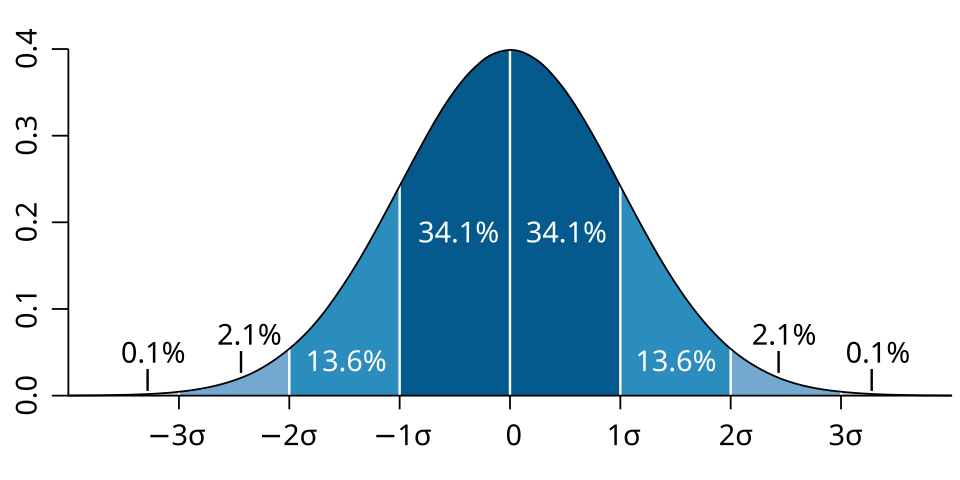

---

``` text
# 표준화 공식
z = (x - 평균) / 표준편차
```

---

## 스케일이 필요한 이유?
- k-NN 처럼 거리 기반 모델은 특성의 숫자 크기에 민감
- 길이와 무게처럼 범위가 다른 단위를 사용할 때
- 유클리드 거리를 계산하면 무게 차이가 거리 계산을 지배하게 된다.

In [28]:
# 유클리드 거리 예시
import numpy as np

A = [20.0, 500.0]   # 길이 20cm, 무게 500g
B = [44.0, 501.0]   # 길이 44cm, 무게 501g
new = [22.0, 499.0]

d_A = np.sqrt((22 - 20)**2 + (499 - 500)**2)  # 약 2.2
d_B = np.sqrt((22 - 44)**2 + (499 - 501)**2)  # 약 22.1

print(' A : ',round(d_A,2),'\n','B : ',round(d_B,2))
print('따라서 모든 특성이 공평하게 말할 수 있도록 스케일을 맞춰줘야한다.')

 A :  2.24 
 B :  22.09
따라서 모든 특성이 공평하게 말할 수 있도록 스케일을 맞춰줘야한다.


### Data Leakage
---
- 훈련/테스트 경계를 어겨서 테스트 정보가 모델에 새어 들어가는 현상
- 테스트 데이터에 ```fit()``` 을 하면 테스트 데이터의 평균, 표준편차를 컨닝한 것이나 다름 없기 때문에 평가 점수를 신뢰할 수 없음.

##### 잘못된 방법
``` python
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

train_scaled = ss.fit_transform(train_input)
test_scaled = ss.fit_transform(test_input)  # 위험! test에 fit 하면 안 됨
```

##### 올바른 방법
``` python
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

train_scaled = ss.fit_transform(train_input)  # train으로 평균, 표준편차 계산
test_scaled = ss.transform(test_input)        # test는 변환만
```

### k-NN 회귀

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import platform

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab, Ubuntu 등)
    # 나눔고딕이 설치되어 있어야 합니다. 없으면 'sudo apt-get install fonts-nanum' 실행
    plt.rc('font', family='NanumGothic')

### 농어 데이터셋

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 데이터 가져오기
df = pd.read_csv('Fish.csv')
perch = df[df['Species'] == 'Perch'].copy().reset_index().drop(columns='index')
perch_length = perch['Length2'].values
perch_weight = perch['Weight'].values


In [34]:
train_input, test_input, train_target, test_target = train_test_split(
    perch_length, perch_weight, random_state=42
)

In [39]:
train_input = train_input.reshape(-1,1)
test_input = test_input.reshape(-1,1)

In [40]:
scaled = StandardScaler()

train_scaled = scaled.fit_transform(train_input)    # train으로 평균, 표준편차 계산
test_scaled = scaled.transform(test_input)          # test는 변환만


#### R² 결정계수
---
- R² : 모델이 데이터를 얼마나 잘 설명하는지 나타내는 회귀 평가 지표


- `R² = 1.0` : 완벽한 예측
- `R² = 0.0` : 항상 평균만 예측하는 것과 비슷함
- `R² < 0` : 평균 예측보다도 못함. 오류가 아니라 진짜 못한 것.


In [41]:
from sklearn.neighbors import KNeighborsRegressor

knr = KNeighborsRegressor()
knr.fit(train_scaled, train_target)

print('test R²:', knr.score(test_scaled, test_target))
print('train R²:', knr.score(train_scaled, train_target))

test R²: 0.992809406101064
train R²: 0.969912706348246


#### MAE
---
-  평균 절대 오차. 예측값이 실제값과 평균적으로 얼마나 차이 나는지 확인한다.

In [45]:
from sklearn.metrics import mean_absolute_error

test_prediction = knr.predict(test_scaled)
mae = mean_absolute_error(test_target, test_prediction)
print(mae)

19.157142857142862


##### Tip
- 분류는 보통 정확도 Accuracy를 많이 보고
- 회귀는 R²로 설명력을 보고 MAE/RMSE로 실제 오차 크기를 같이 본다.

#### k-NN 회귀의 한계 : 외삽 불가
---
- 새 데이터가 오면 이웃을 찾는 k-NN의 특성은 새 데이터가 훈련 범위를 벗어나면 가장 끝에 있는 데이터들만 이웃으로 선택되는 한계가 있다.

In [46]:
knr_3 = KNeighborsRegressor(n_neighbors=3)
knr_3.fit(train_input, train_target)

print(knr_3.predict([[50]]))   # [1033.33]
print(knr_3.predict([[100]]))  # [1033.33]

[1033.33333333]
[1033.33333333]


### 선형 회귀
---
- 데이터를 가장 잘 설명하는 직선을 찾는 모델
- 무게 = w × 길이 + b

- `w` : 가중치, 기울기, 계수
    - 길이가 1cm 증가할 때 무게가 얼마나 증가하는지
- `b` : 편향, 절편
    - 길이가 0일 때의 예측값

In [49]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(train_input, train_target)

print(lr.coef_)       # w
print(lr.intercept_)  # b
print(lr.predict([[50]]))

[39.01714496]
-709.0186449535474
[1241.83860323]


### MSE 손실함수
---
- 평균 제곱 오차 : 예측값과 실제값의 차이를 제곱한 뒤 평균낸 값

```
샘플 1: 실제 300g, 예측 280g → 오차 20 → 제곱 400
샘플 2: 실제 100g, 예측 150g → 오차 -50 → 제곱 2500
샘플 3: 실제 1000g, 예측 950g → 오차 50 → 제곱 2500

MSE = (400 + 2500 + 2500) / 3 = 1800
```

##### 오차 제곱 이유?
- 부호 상쇄 방지
    - +20, -20을 그냥 더하면 0이 되어버린다.
    - 제곱하면 모두 양수가 된다.
- 큰 오차에 더 큰 벌칙
    - 오차 10 → 제곱 100
    - 오차 100 → 제곱 10000

### 경사 하강법
---
- 손실 함수가 가장 작아지는 방향으로 파라미터를 조금씩 이동시키는 방법

```
w ← w - α × ∂J/∂w
b ← b - α × ∂J/∂b

- `J` : 손실 함수
- `α` : 학습률
- `∂J/∂w` : w에 대한 손실 함수의 기울기
- `∂J/∂b` : b에 대한 손실 함수의 기울기

```

### 다항 회귀
---
- 기존 특성에 제곱항, 교차항 등을 추가해서 곡선 패턴을 학습하는 회귀

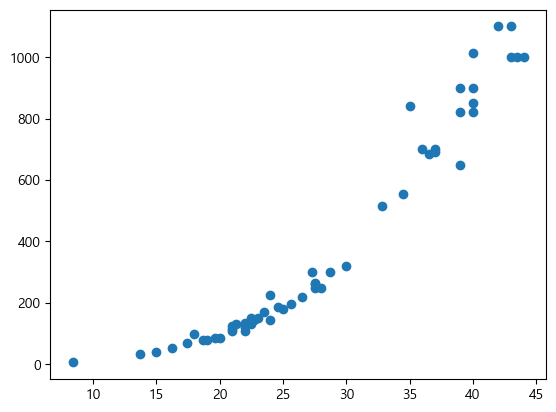

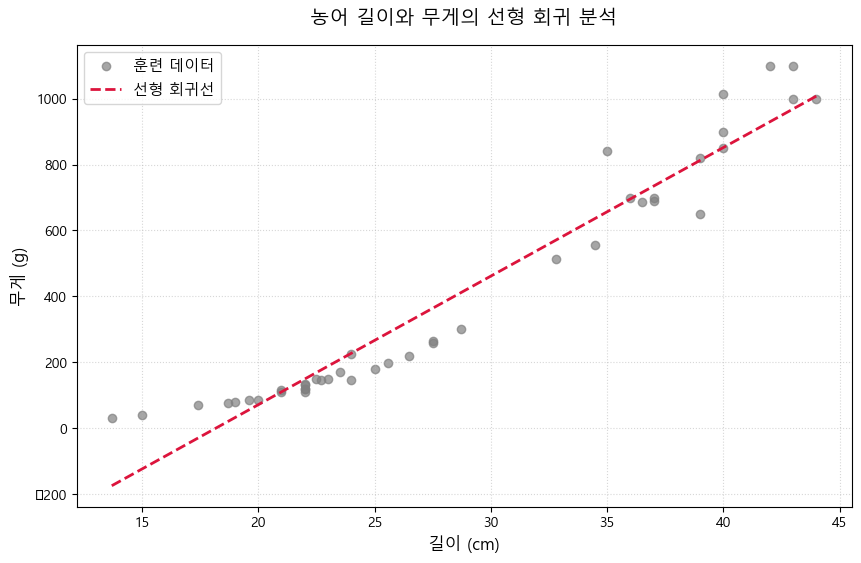

- 농어 데이터 산점도는 직선보다 곡선이 더 잘 맞는다는 것을 보여줌.
- 길이 하나만 쓰면 직선이지만, 길이²을 추가하면 곡선 표현 가능.

In [50]:
# PolynomialFeatures : 전처리 도구, test에서 fit하면 X
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(include_bias=False)
poly.fit(train_input)  # train에만 fit

train_poly = poly.transform(train_input)
test_poly = poly.transform(test_input)

lr = LinearRegression()
lr.fit(train_poly, train_target)

print(lr.coef_, lr.intercept_)
print('train R²:', lr.score(train_poly, train_target))
print('test R²:', lr.score(test_poly, test_target))

[-21.55792498   1.01433211] 116.05021078278372
train R²: 0.9706807451768623
test R²: 0.9775935108325123


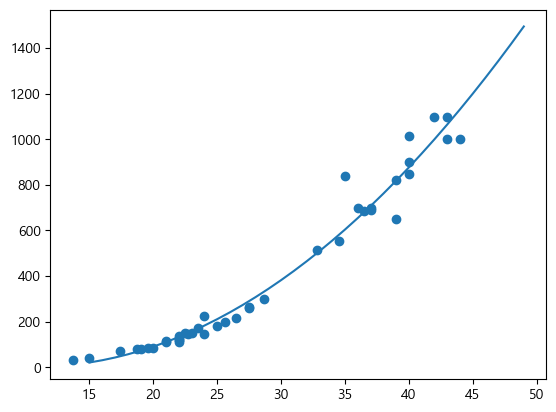

In [52]:
point = np.arange(15,50) # 점의 범위
plt.scatter(train_input, train_target)
# plt.plot(point, 1.01*point **2 - 21*point + 116)
plt.plot(point, lr.coef_[1] * (point ** 2) + lr.coef_[0] * point + lr.intercept_)

### 캘리포니아 주택가격 데이터셋
---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import platform
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab, Ubuntu 등)
    # 나눔고딕이 설치되어 있어야 합니다. 없으면 'sudo apt-get install fonts-nanum' 실행
    plt.rc('font', family='NanumGothic')

##### 데이터셋 로드

In [62]:
from sklearn.datasets import fetch_california_housing

# as_frame=True : 판다스 데이터프레임으로 반환
california = fetch_california_housing(as_frame=True)
california.data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [61]:
california.target

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

In [71]:
# 특성 데이터와 타겟 데이터 분리
x_data = california.data.values
y_data = california.target

##### train_test_split

In [120]:
x_train, x_test, y_train, y_test = train_test_split(
    x_data, y_data, random_state=42
)

##### 스케일링

In [74]:
scaled = StandardScaler()

scaled_train = scaled.fit_transform(x_train)
scaled_test = scaled.transform(x_test)

In [75]:
from sklearn.neighbors import KNeighborsRegressor

kr = KNeighborsRegressor()
kr.fit(scaled_train, y_train)

print('test R² : ', kr.score(scaled_test, y_test))
print('train R² : ', kr.score(scaled_train, y_train))

test R² :  0.6737569252627673
train R² :  0.7944311478851148


In [76]:
from sklearn.metrics import mean_absolute_error

test_pred = kr.predict(scaled_test)
m = mean_absolute_error(y_test, test_pred)
print(m)

0.4460739527131783


#### k-NN 회귀선 시각화 자동화 함수

In [88]:
# 2. 데이터 로드 (전역 변수로 한 번만 로드)
california = fetch_california_housing(as_frame=True)


def plot_knn_regression(feature_name, n_neighbors=5):
    """
    캘리포니아 데이터셋의 특정 특성과 주택 가격 간의 k-NN 회귀선을 그리는 함수
    
    :param feature_name: 분석할 특성 이름 (str)
    :param n_neighbors: k-NN의 이웃 수 (int, 기본값 5)
    """
    # 예외 처리: 데이터셋에 없는 특성 이름이 들어왔을 경우
    if feature_name not in california.data.columns:
        print(f"❌ '{feature_name}'은(는) 데이터셋에 존재하지 않는 특성입니다.")
        print(f"👉 사용 가능한 특성: {list(california.data.columns)}")
        return

    # 1. 데이터 추출
    X = california.data[[feature_name]].values
    y = california.target.values

    # 2. 데이터 스케일링
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 3. 모델 학습
    kr_model = KNeighborsRegressor(n_neighbors=n_neighbors)
    kr_model.fit(X_scaled, y)

    # 4. 회귀선을 위한 가상 데이터 생성
    x_axis = np.linspace(X_scaled.min(), X_scaled.max(), 1000).reshape(-1, 1)
    y_pred = kr_model.predict(x_axis)

    # 5. 시각화
    plt.figure(figsize=(10, 6))
    
    # 실제 데이터 산점도
    plt.scatter(X_scaled, y, color='lightgray', alpha=0.4, label='실제 데이터 분포')
    
    # k-NN 회귀선
    plt.plot(x_axis, y_pred, color='red', linewidth=2, 
             label=f'k-NN 회귀선 (k={n_neighbors})')

    plt.title(f'캘리포니아 주택 데이터: {feature_name} vs 주택 가격')
    plt.xlabel(f'{feature_name} (Standardized)')
    plt.ylabel('주택 가격 (Median House Value)')
    plt.legend()
    plt.grid(True, linestyle='--')
    plt.show()

- MedInc: 블록 내 가구들의 중간 소득
- HouseAge: 블록 내 주택의 중간 연식
- AveRooms: 가구당 평균 방 개수
- AveBedrms: 가구당 평균 침실 개수
- Population: 블록 내 거주 인구수
- AveOccup: 가구당 평균 가구원 수
- Latitude: 위도
- Longitude: 경도

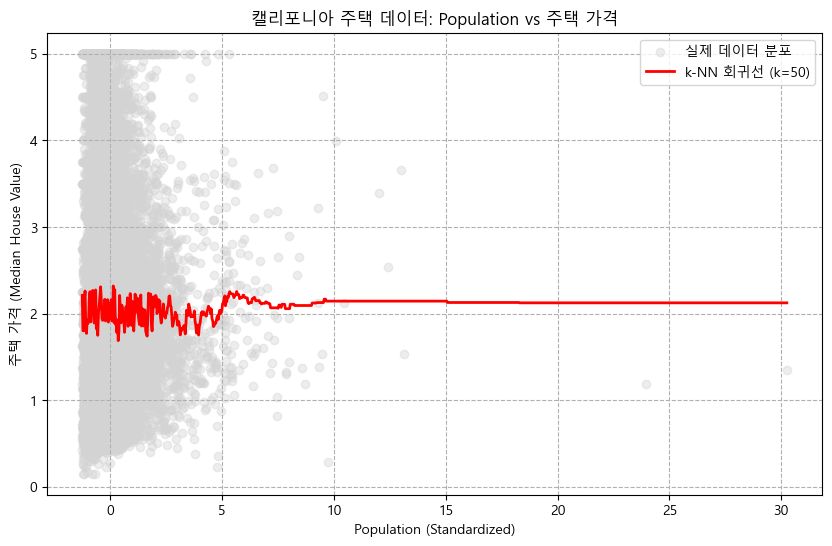

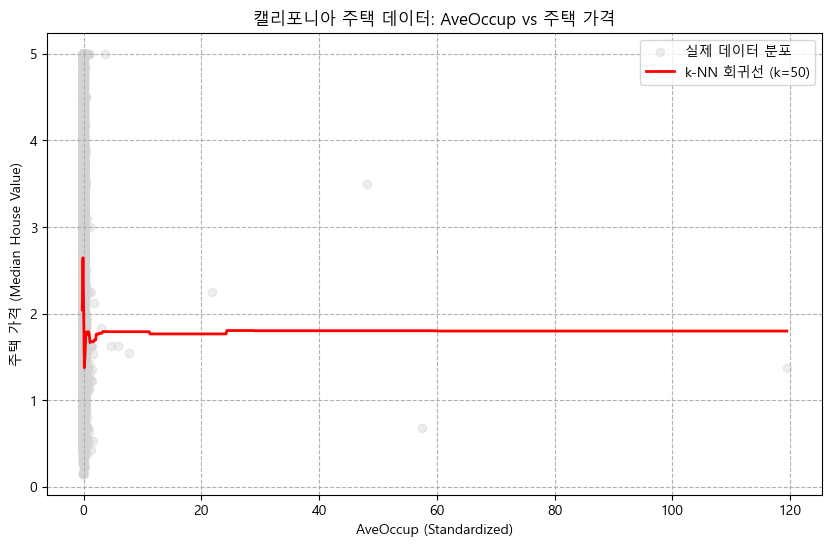

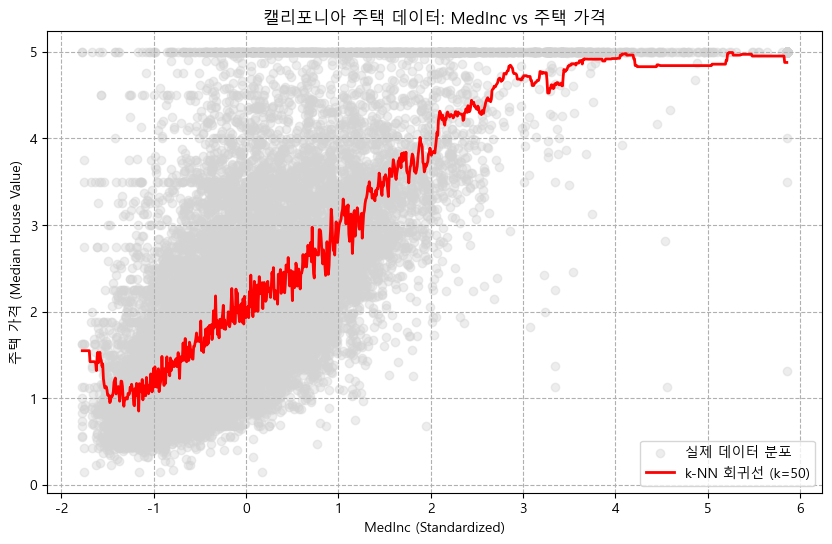

In [121]:
# 인구
plot_knn_regression('Population', n_neighbors=50)
# 방 개수
plot_knn_regression('AveOccup', n_neighbors=50)
# 소득
plot_knn_regression('MedInc', n_neighbors=50)

### 다항회귀
---

In [92]:

from sklearn.metrics import r2_score

# 1. 한글 폰트 및 마이너스 깨짐 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False
# 2. 데이터 로드
california = fetch_california_housing(as_frame=True)


def compare_knn_and_poly(feature_name, degree=3, n_neighbors=5):
    """
    특정 피처에 대해 k-NN 회귀와 다항 회귀 모델의 성능(R²)을 비교하고 그래프를 그리는 함수
    
    :param feature_name: 분석할 특성 이름 (str)
    :param degree: 다항 회귀의 차수 (int, 기본값 3차식)
    :param n_neighbors: k-NN의 이웃 수 (int, 기본값 5)
    """
    if feature_name not in california.data.columns:
        print(f"❌ '{feature_name}'은(는) 존재하지 않는 특성입니다.")
        return

    # 1. 데이터 추출
    X = california.data[[feature_name]].values
    y = california.target.values

    # 2. 데이터 스케일링
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 3. [모델 1] k-NN 회귀 모델 학습 및 예측
    knn_model = KNeighborsRegressor(n_neighbors=n_neighbors)
    knn_model.fit(X_scaled, y)
    y_knn_train_pred = knn_model.predict(X_scaled)
    knn_r2 = r2_score(y, y_knn_train_pred)

    # 4. [모델 2] 다항 회귀 모델 학습 및 예측
    # 차수(degree)만큼 고차항 변환 (예: x -> x, x², x³)
    poly_features = PolynomialFeatures(degree=degree)
    X_poly = poly_features.fit_transform(X_scaled)
    
    poly_model = LinearRegression()
    poly_model.fit(X_poly, y)
    y_poly_train_pred = poly_model.predict(X_poly)
    poly_r2 = r2_score(y, y_poly_train_pred)

    # 5. 콘솔에 결과(R²) 출력
    print(f"📊 [{feature_name}] 모델 성능 비교 (전체 데이터 기준 R²)")
    print(f"   - k-NN 회귀 (k={n_neighbors}) R² : {knn_r2:.4f}")
    print(f"   - 다항 회귀 ({degree}차식) R²   : {poly_r2:.4f}")
    print("-" * 50)

    # 6. 회귀선을 그리기 위한 가상의 촘촘한 데이터 생성
    x_axis = np.linspace(X_scaled.min(), X_scaled.max(), 1000).reshape(-1, 1)
    
    # 가상 데이터에 대한 두 모델의 예측값 계산
    y_axis_knn_pred = knn_model.predict(x_axis)
    
    x_axis_poly = poly_features.transform(x_axis) # 가상 데이터도 고차항 변환 필요
    y_axis_poly_pred = poly_model.predict(x_axis_poly)

    # 7. 시각화
    plt.figure(figsize=(12, 6))
    
    # 실제 데이터 분포
    plt.scatter(X_scaled, y, color='lightgray', alpha=0.4, label='실제 데이터 분포')
    
    # k-NN 회귀선 (초록색 꺾은선)
    plt.plot(x_axis, y_axis_knn_pred, color='forestgreen', linewidth=2, 
             label=f'k-NN 회귀선 (k={n_neighbors}, R²={knn_r2:.2f})')
    
    # 다항 회귀선 (빨간색 부드러운 곡선)
    plt.plot(x_axis, y_axis_poly_pred, color='crimson', linewidth=2.5, 
             label=f'{degree}차 다항 회귀선 (R²={poly_r2:.2f})')

    plt.title(f'k-NN vs 다항 회귀 모델 비교 ({feature_name})')
    plt.xlabel(f'{feature_name} (Standardized)')
    plt.ylabel('주택 가격 (Median House Value)')
    plt.legend()
    plt.grid(True, linestyle='--')
    plt.show()

##### 실행

📊 [MedInc] 모델 성능 비교 (전체 데이터 기준 R²)
   - k-NN 회귀 (k=5) R² : 0.5763
   - 다항 회귀 (3차식) R²   : 0.4862
--------------------------------------------------


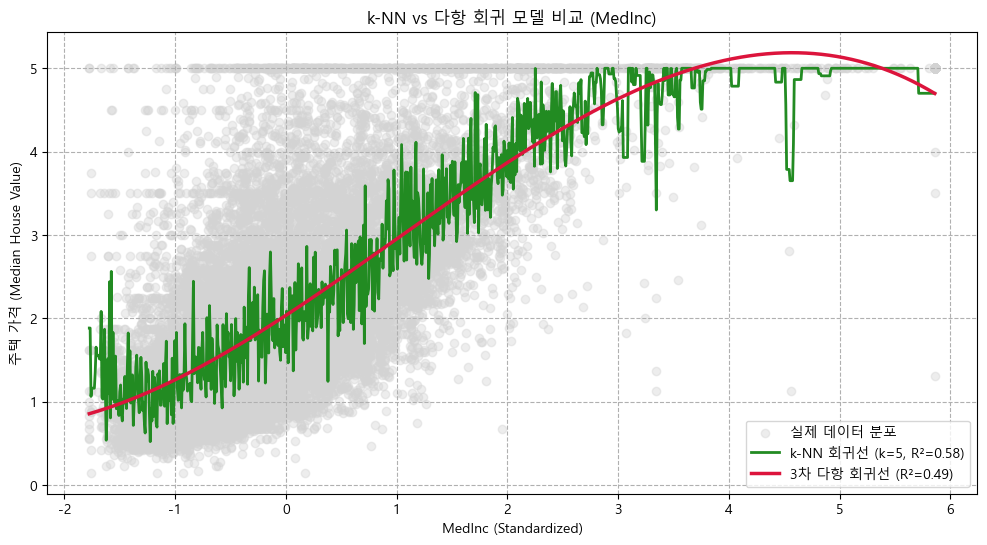

In [114]:
# 소득수준
compare_knn_and_poly('MedInc', degree=3, n_neighbors=5)

#### 인사이트
- 소득(MedInc) 외에는 집값과 정비례하거나 반비례하는 뚜렷한 '선형 관계'가 보이지 않음.
- 이는 피처와 라벨의 관계가 선형일 때 가장 효과적인 선형 회귀 모델의 한계를 보여주며, 캘리포니아 주택가격 데이터셋의 피처 대부분이 여러 특성이 얽혀 있는 복잡한 상호작용의 피처들로 이루어져 있음을 시사함(비선형).
- 따라서 캘리포니아 데이터셋을 분석하기 위해 다른 모델 적용을 시도해볼 수 있음.
- 의사결정나무(Decision Tree), 랜덤 포레스트(Random Forest), XGBoost

#### 랜덤 포레스트 모델 예측
---

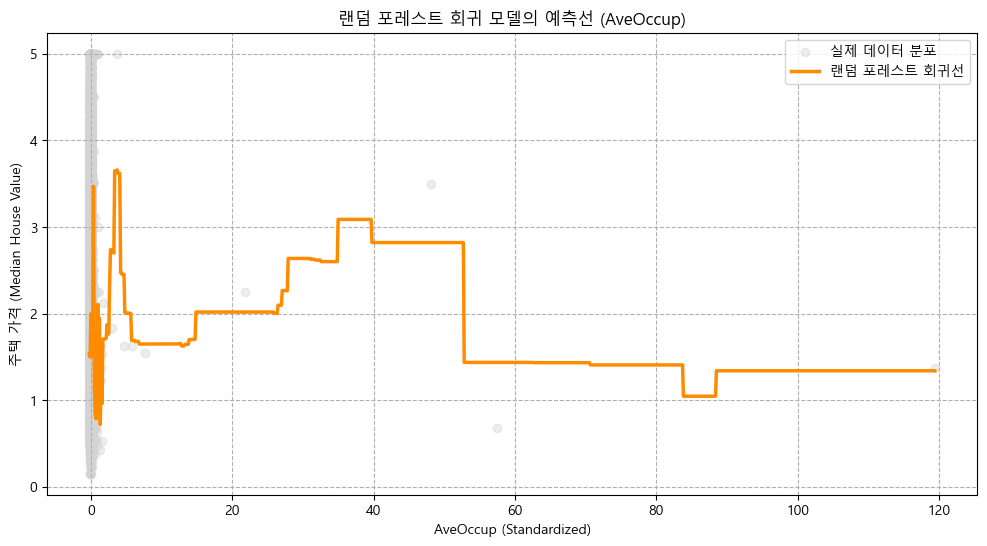

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import platform
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor  # 랜덤 포레스트 임포트
from sklearn.preprocessing import StandardScaler

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드 및 '인구(Population)' 선택
california = fetch_california_housing(as_frame=True)
feature_name = 'AveOccup'  # 선형 모델이 갈피를 못 잡던 '가구원수'로 테스트!

X = california.data[[feature_name]].values
y = california.target.values

# 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 랜덤 포레스트 모델 학습 (트리 100개의 평균)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_scaled, y)

# 회귀선 시각화를 위한 가상 데이터 생성
x_axis = np.linspace(X_scaled.min(), X_scaled.max(), 1000).reshape(-1, 1)
y_rf_pred = rf_model.predict(x_axis)

# 시각화
plt.figure(figsize=(12, 6))
plt.scatter(X_scaled, y, color='lightgray', alpha=0.4, label='실제 데이터 분포')

# 랜덤 포레스트 회귀선 (계단 모양)
plt.plot(x_axis, y_rf_pred, color='darkorange', linewidth=2.5, label='랜덤 포레스트 회귀선')

plt.title(f'랜덤 포레스트 회귀 모델의 예측선 ({feature_name})')
plt.xlabel(f'{feature_name} (Standardized)')
plt.ylabel('주택 가격 (Median House Value)')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

### 랜덤 포레스트 특성 중요도 확인
---

테스트 데이터 R² 점수: 0.8051
--------------------------------------------------


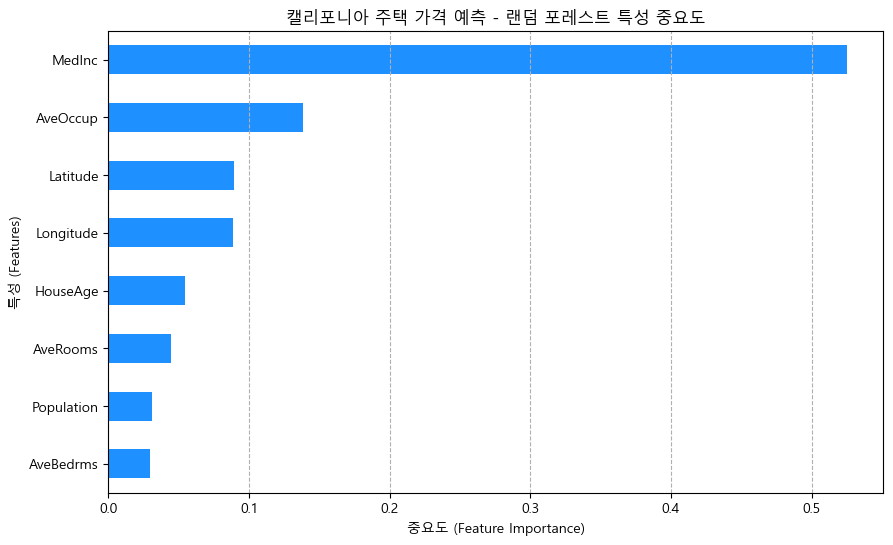

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import platform
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# 1. 한글 폰트 및 마이너스 깨짐 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로드 및 분할 (모든 특성 사용)
california = fetch_california_housing(as_frame=True)
X = california.data
y = california.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 랜덤 포레스트 모델 학습 (트리 기반 모델은 스케일링이 결과에 영향을 주지 않으므로 생략 가능)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 모델 전체 성능(R²)도 확인해보세요 ㅋ
print(f"테스트 데이터 R² 점수: {rf_model.score(X_test, y_test):.4f}")
print("-" * 50)

# 4. 특성 중요도 추출 및 데이터프레임 정렬
importances = rf_model.feature_importances_
feature_names = X.columns

# 보기 좋게 판다스 시리즈로 변환 후 내림차순 정렬
rf_importances = pd.Series(importances, index=feature_names).sort_values(ascending=True)

# 5. 특성 중요도 시각화 (수평 바 차트)
plt.figure(figsize=(10, 6))
rf_importances.plot(kind='barh', color='dodgerblue')
plt.title('캘리포니아 주택 가격 예측 - 랜덤 포레스트 특성 중요도')
plt.xlabel('중요도 (Feature Importance)')
plt.ylabel('특성 (Features)')
plt.grid(axis='x', linestyle='--')
plt.show()

#### 랜덤 포레스트 결정계수 구하기
---

In [117]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# 데이터 로드
california = fetch_california_housing(as_frame=True)
X = california.data
y = california.target

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 랜덤 포레스트 모델 학습
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# 1. 일반 결정계수 (R²) 구하기
test_r2 = rf.score(X_test, y_test)

# 2. 수정된 결정계수 (Adjusted R²) 직접 계산하기
n = X_test.shape[0]  # 테스트 데이터 샘플 수 (4128개)
p = X_test.shape[1]  # 특성 개수 (8개)

adj_r2 = 1 - ((1 - test_r2) * (n - 1) / (n - p - 1))

print(f"📊 랜덤 포레스트 테스트 결과")
print(f"   - 일반 결정계수 (R²)       : {test_r2:.4f}")
print(f"   - 수정된 결정계수 (Adj R²) : {adj_r2:.4f}")

📊 랜덤 포레스트 테스트 결과
   - 일반 결정계수 (R²)       : 0.8051
   - 수정된 결정계수 (Adj R²) : 0.8047


##### 인사이트
- 통상적으로 사회 현상에 대한 데이터 분석에서는 결정계수 0.5이상이면 유의미한 분석이라고 볼 수 있음.
- 랜덤 포레스트이 결정계수는 약 0.8 로 선형회귀모델의 결정계수보다 훨씬 높은 모델의 설명력을 보여줌.
- 그러나 선형회귀모델과 마찬가지로 집값에 가장 큰 영향을 미친 피처는 소득 수준으로 나타남.
- 위치를 나타내는 위도, 경도와 가족의 수도 상위에 있는데 이는 일반적인 집값 형성에 대한 사회적 인식과 비교했을 때와 일치하다고 볼 수 있음(위치도 중요하지만 가족의 수에 따라 집의 크기가 달라져야 하기 때문)
- 따라서 캘리포니아 주택가격 데이터셋은 각 특성들이 선형적이기 보다는 비선형적이라 복합적으로 작용하는 데이터셋이라 볼 수 있으며 선형 회귀 모델에서도 유의미한 결과를 보였지만 랜덤 포레스트 모델로 분석했을 때 훨씬 더 유의미한 설명력을 가진다고 볼 수 있으며, 집값에 영향을 미치는 상위 요인으로 소득과 위치, 가족의 수 특성이 꼽히는 것은 모델이 사회적으로 보편적인 집값 형성 요인을 반영했다고 볼 수 있다.

#### [최종 결론 요약]
- 캘리포니아 주택 가격 데이터셋은 각 특성이 독립적이기보다 복합적이고 비선형적으로 작용하는 데이터셋이다.
- 선형 회귀 모델도 $R^2$ 0.6 수준으로 사회 현상 분석 기준(0.5 이상)을 충족하는 유의미한 결과를 보였으나, 특성 간의 복잡한 상호작용을 스스로 학습하는 랜덤 포레스트 모델을 적용했을 때 $R^2$ 약 0.8로 훨씬 더 압도적인 설명력을 가짐을 확인하였다.
- 특히, 두 모델 모두에서 집값의 가장 강력한 요인으로 **소득 수준(MedInc)**이 꼽혔으며, 랜덤 포레스트에서는 단일 선형 관계가 없던 **가구원(AveOccup)**과 **위도(Latitude)와 경도(Longitude)**의 중요도가 상위권으로 나타났다.
- 이는 대도시 해안가 중심의 입지 조건(LA, 샌프란시스코 등)과 가구원의 수가 복합적으로 집값에 작용하는 현실 세계의 보편적인 부동산 형성 요인을 모델이 정확히 반영하고 있음을 시사한다.